# Learning Fusion 5 — Hands-On: Point Cloud Basics

This notebook lets you **hold a real KITTI point cloud in your hands**. No ML, no model —
just the raw 3D data, one `.bin` file at a time. After this, "point cloud" is concrete, not
abstract. It backs the raw-load idiom used everywhere in the repo.

The load idiom and BEV helpers mirror your repo:
- `np.fromfile(...).reshape(-1, 4)`  ↔  `data/loaders/paired_loader.py` (line 68)
- `points_to_bev_image`            ↔  `common/geometry/bev.py`
- `Calib` + projection             ↔  `common/sensors/calibration.py`, `common/sensors/projection.py`

It is **self-contained** — runs as-is in **Google Colab** (numpy + matplotlib preinstalled;
open3d optional). On your laptop it reads a real KITTI `.bin` from `data/kitti_sample/`;
if that folder isn't there, it builds a synthetic car+ground cloud so the notebook never
breaks. Five real frames were fetched into `data/kitti_sample/` by
`notebooks/_fetch_kitti_sample.py` (~40 MB, not 27 GB — zip64 range extraction).

**Convention (KITTI):** camera frame — **x right, y down, z forward**. LiDAR (velo) frame —
**x forward, y left, z up**. The `.bin` files are in the velo frame.

> Run top-to-bottom. Each cell prints the shape and a few numbers — that's the point. Open
> `LEARNING_FUSION.html` Section 5 side-by-side. Change `FRAME_ID` to `1..4` to see other frames.


In [1]:
import os, numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # registers the 3d projection

np.random.seed(0)

# ---- config: mirrors config/base.yaml + data/kitti_sample layout ----
cfg = dict(
    frame_id=1,                       # 0..4 available; 1 has a Car+Truck for the box overlay
    range_m=35.0,                     # base.yaml bev range; we filter points to +/-this
    res_m=0.20,                       # base.yaml bev res -> 350x350 grid here
    max_h=3.0,                        # height normalization for BEV channels (bev.py)
)
FRAME_ID = cfg["frame_id"]
RANGE, RES, MAXH = cfg["range_m"], cfg["res_m"], cfg["max_h"]
Hg = Wg = int(2 * RANGE / RES)        # 350 x 350 BEV grid
SAMPLE_DIR = "data/kitti_sample"

# open3d is optional (needs the `fusion` conda env on your laptop; not in Colab)
try:
    import open3d as o3d
    HAS_O3D = True
except ImportError:
    HAS_O3D = False

print(f"frame id       : {FRAME_ID}")
print(f"BEV grid       : {Hg} x {Wg}  (range +/-{RANGE} m, res {RES} m)")
print(f"open3d         : {'available' if HAS_O3D else 'not installed (matplotlib 3D path will be used)'}")
print(f"sample dir     : {SAMPLE_DIR}  ({'present' if os.path.isdir(os.path.join(SAMPLE_DIR, 'velodyne')) else 'absent -> synthetic fallback'})")


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
frame id       : 1
BEV grid       : 350 x 350  (range +/-35.0 m, res 0.2 m)
open3d         : available
sample dir     : data/kitti_sample  (present)


In [2]:
# ---- THE 10-LINE EXERCISE: load a KITTI .bin point cloud ----
# A .bin is a flat array of float32: [x, y, z, intensity, x, y, z, intensity, ...].
# Four floats per point. That's it. No header, no metadata, no structure.
#
# This is the exact idiom from data/loaders/paired_loader.py:
#   pts = np.fromfile(path, dtype=np.float32).reshape(-1, 4)

bin_path = os.path.join(SAMPLE_DIR, "velodyne", f"{FRAME_ID:06d}.bin")

def make_synthetic_cloud(n_car=240, n_ground=200, seed=0):
    """A car (surface points) + ground, in the velo frame. Fallback if no .bin."""
    rng = np.random.default_rng(seed)
    car = []
    for _ in range(n_car):
        face = rng.integers(3)
        p = [10.0 + rng.uniform(-2, 2),   # x: forward, car length ~4m
             1.0 + rng.uniform(-1, 1),    # y: left/right, car width ~2m
             0.5 + rng.uniform(-0.4, 0.4)] # z: up, car height ~1.5m
        if face == 0: p[0] = 10.0 + rng.choice([-2, 2])    # front/back face
        elif face == 1: p[1] = 1.0 + rng.choice([-1, 1])   # left/right face
        else: p[2] = 0.5 + rng.choice([-0.4, 0.4])        # top/bottom face
        car.append(p + [0.55])                              # intensity
    ground = [list(rng.uniform(2, 25, 1)) + list(rng.uniform(-6, 6, 1)) + [0.02, 0.10]
              for _ in range(n_ground)]
    return np.array(car + ground, np.float32)

if os.path.exists(bin_path):
    pts = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)
    SOURCE = f"REAL KITTI frame {FRAME_ID:06d}  ({bin_path})"
else:
    pts = make_synthetic_cloud()
    SOURCE = "synthetic car+ground cloud  (run notebooks/_fetch_kitti_sample.py for real data)"

x, y, z, intensity = pts[:, 0], pts[:, 1], pts[:, 2], pts[:, 3]
print(f"source         : {SOURCE}")
print(f"shape          : {pts.shape}   (N, 4) = (x, y, z, intensity)  in the velo frame")
print(f"dtype          : {pts.dtype}")
print(f"N points       : {len(pts):,}")
print(f"x (forward)    : [{x.min():.2f}, {x.max():.2f}] m")
print(f"y (left)       : [{y.min():.2f}, {y.max():.2f}] m")
print(f"z (up)         : [{z.min():.2f}, {z.max():.2f}] m")
print(f"intensity      : [{intensity.min():.2f}, {intensity.max():.2f}]")


source         : REAL KITTI frame 000001  (data/kitti_sample\velodyne\000001.bin)
shape          : (120268, 4)   (N, 4) = (x, y, z, intensity)  in the velo frame
dtype          : float32
N points       : 120,268
x (forward)    : [-79.43, 77.00] m
y (left)       : [-55.32, 57.72] m
z (up)         : [-7.29, 2.90] m
intensity      : [0.00, 0.99]


## What *is* a point cloud?

A point cloud is an **unstructured `(N, 4)` array**. Not a grid, not an image — just a list
of `(x, y, z, intensity)` rows. `N` varies per frame (here, ~115k). There is no width, no
height, no channels; the only structure is the 3D position of each point.

- **x, y, z** are in the **velo (LiDAR) frame**: x = forward, y = left, z = up. This is *not*
  the camera frame (x right, y down, z forward) — the `Calib` transform converts between them.
- **intensity** is the return strength, 0..1. Roads are dark, cars and lane markings are bright.
- It is **sparse and irregular**: more points on close surfaces, fewer on far ones. A camera
  gives a dense `(H, W, 3)` grid; a LiDAR gives a sparse `(N, 4)` cloud. That sparsity is why
  detection-from-point-clouds (PointPillars, etc.) has its own encoder instead of a CNN.

The rest of this notebook makes these numbers **visible**.


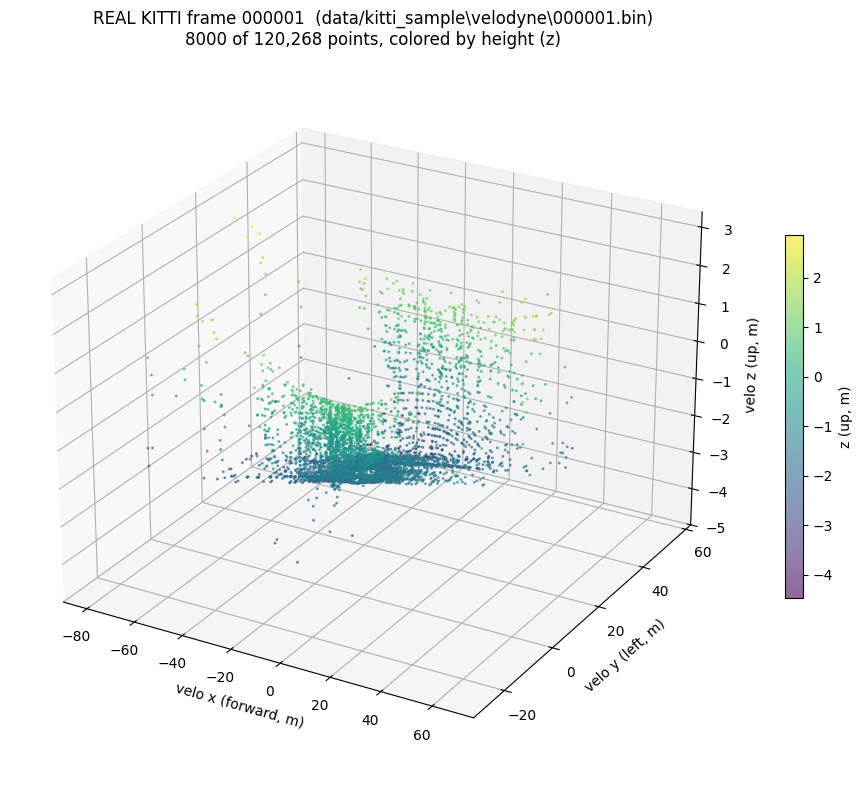

Notice: the ground is the flat band at z~0; cars are blobs that stick up.


In [3]:
# ---- 3D scatter: see the cloud as a cloud, not numbers ----
# Subsample for speed (matplotlib 3D struggles with >10k points).
n_plot = min(8000, len(pts))
idx = np.random.choice(len(pts), n_plot, replace=False)
pp = pts[idx]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(pp[:, 0], pp[:, 1], pp[:, 2], c=pp[:, 2], cmap="viridis", s=1.2, alpha=0.6)
ax.set_xlabel("velo x (forward, m)"); ax.set_ylabel("velo y (left, m)"); ax.set_zlabel("velo z (up, m)")
ax.set_title(f"{SOURCE}\n{n_plot} of {len(pts):,} points, colored by height (z)")
fig.colorbar(sc, ax=ax, shrink=0.5, label="z (up, m)")
ax.view_init(elev=25, azim=-60)
plt.tight_layout(); plt.show()
print("Notice: the ground is the flat band at z~0; cars are blobs that stick up.")


In [4]:
# ---- open3d: the interactive 3D viewer ----
# On a laptop (fusion env): opens an external window (rotate/zoom/pan).
# In Colab / headless: uses the plotly inline renderer with a SUBSAMPLED cloud (plotly
# struggles above ~20k points), which renders in the notebook output.
#
# NOTE: draw_geometries() does NOT raise on headless failure -- it silently prints GLFW
# warnings and returns. So we detect Colab BEFORE choosing which renderer to use.
# Windows/macOS/Linux laptops all have a display; only Colab is headless.
import sys, platform
IN_COLAB = 'google.colab' in sys.modules
# DISPLAY env var is X11/Linux only; Windows and macOS always have a display.
HAS_DISPLAY = (not IN_COLAB) and (platform.system() != 'Linux' or os.environ.get('DISPLAY', '') != '')

if HAS_O3D and os.path.exists(bin_path):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts[:, :3])
    # color by height: roads blue, cars orange
    z_norm = np.clip((pts[:, 2] - z.min()) / max(z.max() - z.min(), 1e-6), 0, 1)
    pcd.colors = o3d.utility.Vector3dVector(plt.cm.viridis(z_norm)[:, :3])
    if HAS_DISPLAY:
        # laptop with a real display -> windowed viewer (works on Windows/macOS)
        o3d.visualization.draw_geometries([pcd], window_name=f"KITTI frame {FRAME_ID:06d}")
        print("Opened the open3d window. Rotate with left-drag, zoom with scroll, pan with right-drag.")
    else:
        # Colab / headless -> plotly inline. Subsample to ~15k pts so plotly stays responsive.
        n_pl = min(15000, len(pts))
        idx_pl = np.random.choice(len(pts), n_pl, replace=False)
        pcd_pl = o3d.geometry.PointCloud()
        pcd_pl.points = o3d.utility.Vector3dVector(pts[idx_pl, :3])
        pcd_pl.colors = o3d.utility.Vector3dVector(plt.cm.viridis(z_norm[idx_pl])[:, :3])
        try:
            o3d.visualization.draw_plotly([pcd_pl], window_name=f"KITTI frame {FRAME_ID:06d}")
            print(f"Rendered inline with plotly (Colab / headless mode, {n_pl} of {len(pts):,} pts).")
        except Exception as e:
            print(f"plotly inline viewer unavailable: {e}")
            print("Use the matplotlib 3D scatter cell above -- it always works.")
else:
    print("open3d not available or no real .bin -- the matplotlib 3D plot above is the viewer.")
    print("To enable on laptop: conda activate fusion  (open3d 0.19.0 is installed there)")
    print("To enable in Colab: !pip install open3d  (then re-run this cell)")


Opened the open3d window. Rotate with left-drag, zoom with scroll, pan with right-drag.


## Range filter

LiDAR sees to ~100 m, but for driving we only care about a box around the ego car. Filter by
**range** — keep points within `range_m` of the origin. This turns ~115k raw points into a
clean ~40k forward-region set. The repo does this implicitly via the BEV grid bounds.

raw             : 120,268 points
within +/-35.0 m : 116,461 points  (kept 96.8%)
outside range   : 3,807 points  (dropped 3.2%)


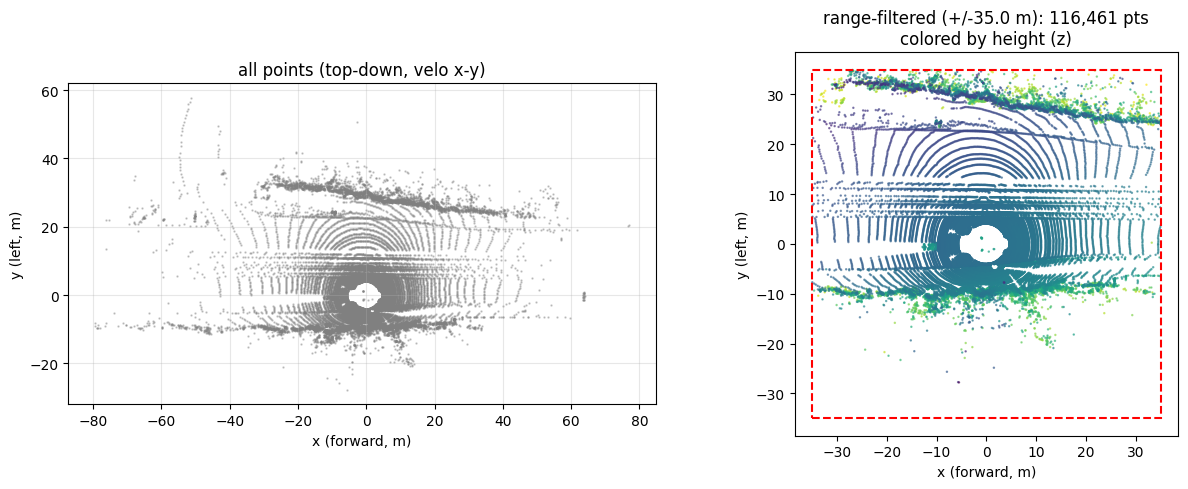

In [5]:
# ---- range filter: keep points within +/-RANGE in x, y ----
# The repo's BEV grid only covers [-range, range] m, so points outside are dropped.
range_mask = (np.abs(x) <= RANGE) & (np.abs(y) <= RANGE)
pts_in = pts[range_mask]
pts_out = pts[~range_mask]
print(f"raw             : {len(pts):,} points")
print(f"within +/-{RANGE} m : {len(pts_in):,} points  (kept {100*len(pts_in)/len(pts):.1f}%)")
print(f"outside range   : {len(pts_out):,} points  (dropped {100*len(pts_out)/len(pts):.1f}%)")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(pts[::4, 0], pts[::4, 1], s=0.5, c="gray", alpha=0.4)
ax[0].set_title("all points (top-down, velo x-y)"); ax[0].set_xlabel("x (forward, m)"); ax[0].set_ylabel("y (left, m)")
ax[0].set_aspect("equal"); ax[0].grid(True, alpha=0.3)
ax[1].scatter(pts_in[::3, 0], pts_in[::3, 1], s=0.6, c=pts_in[::3, 2], cmap="viridis", alpha=0.6)
ax[1].set_title(f"range-filtered (+/-{RANGE} m): {len(pts_in):,} pts\ncolored by height (z)")
ax[1].set_xlabel("x (forward, m)"); ax[1].set_ylabel("y (left, m)"); ax[1].set_aspect("equal")
ax[1].add_patch(plt.Rectangle((-RANGE, -RANGE), 2*RANGE, 2*RANGE, fill=False, edgecolor="red", lw=1.5, ls="--"))
plt.tight_layout(); plt.show()


## Color by height

Coloring by z (up) makes the **road flat** and **cars stick up**. This is the single most
useful visualization for a driving point cloud. The repo's `points_to_bev_image` uses
`-y / max_h` (height above ground) as the first BEV channel — here we do the same in 3D.

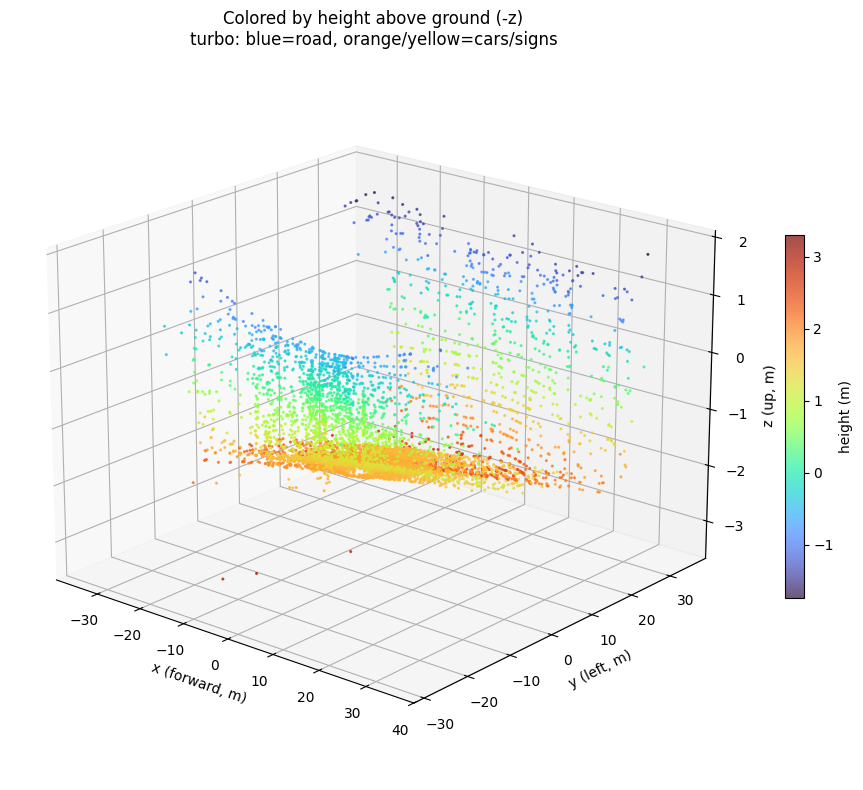

The flat blue band is the road; the warm blobs are cars, poles, and vegetation.


In [6]:
# ---- color by height: the road is flat, cars stick up ----
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
pp = pts_in[np.random.choice(len(pts_in), min(8000, len(pts_in)), replace=False)]
height = -pp[:, 2]   # height above ground (velo z up; ground ~0 -> -z is small for ground)
sc = ax.scatter(pp[:, 0], pp[:, 1], pp[:, 2], c=height, cmap="turbo", s=1.5, alpha=0.7)
ax.set_xlabel("x (forward, m)"); ax.set_ylabel("y (left, m)"); ax.set_zlabel("z (up, m)")
ax.set_title("Colored by height above ground (-z)\nturbo: blue=road, orange/yellow=cars/signs")
fig.colorbar(sc, ax=ax, shrink=0.5, label="height (m)")
ax.view_init(elev=20, azim=-50)
plt.tight_layout(); plt.show()
print("The flat blue band is the road; the warm blobs are cars, poles, and vegetation.")


## Project to BEV by hand

A **bird's-eye-view (BEV)** map is a top-down grid. To make one: bin each point's `(x, y)`
into a 2D array. That's it. This is exactly what `points_to_bev_image` in
`common/geometry/bev.py` does — here it is in 3 lines of numpy.

The grid is centered on the ego car: cell `(r, c)` covers
`x = -range + (r+0.5)*res` (forward) and `y = -range + (c+0.5)*res` (left).


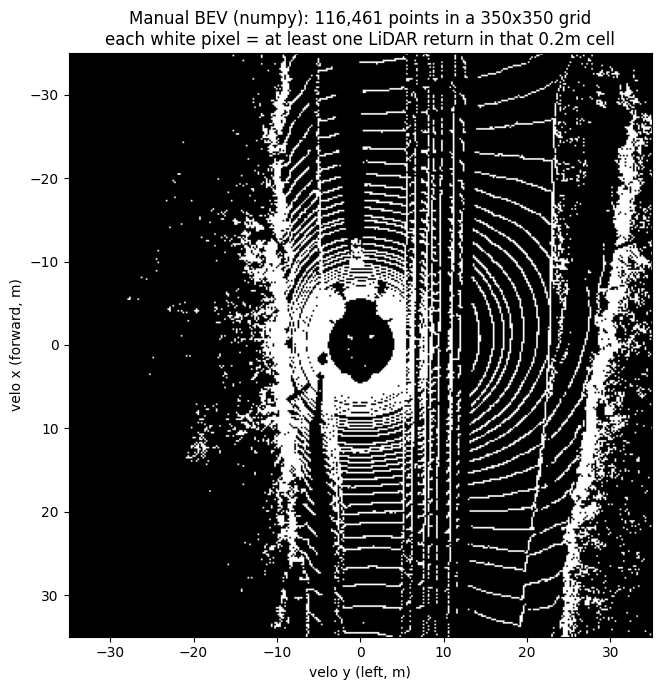

That's a BEV. Cars are the small blobs; the road is the streaky band. You just built one.


In [7]:
# ---- THE 10-LINE BEV: bin (x, y) into a 2D grid with numpy ----
# This is the exercise. Everything below is just plotting.
r = ((pts_in[:, 0] + RANGE) / RES).astype(int)   # velo x = forward -> row
c = ((pts_in[:, 1] + RANGE) / RES).astype(int)   # velo y = left    -> col
valid = (r >= 0) & (r < Hg) & (c >= 0) & (c < Wg)
bev = np.zeros((Hg, Wg), np.float32)
bev[r[valid], c[valid]] = 1.0                     # density: any hit -> 1

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(bev, cmap="gray", extent=[-RANGE, RANGE, RANGE, -RANGE])
ax.set_xlabel("velo y (left, m)"); ax.set_ylabel("velo x (forward, m)")
ax.set_title(f"Manual BEV (numpy): {len(pts_in):,} points in a {Hg}x{Wg} grid\n"
             f"each white pixel = at least one LiDAR return in that {RES}m cell")
plt.tight_layout(); plt.show()
print("That's a BEV. Cars are the small blobs; the road is the streaky band. You just built one.")


### BEV with 3 channels (height, intensity, density)

A single density map is fine for visualization, but the model wants **features per cell**.
`points_to_bev_image` in `common/geometry/bev.py` builds a 3-channel BEV:
- **height** = `-z / max_h` (normalized, 0..1) — tall things are bright
- **intensity** = the LiDAR return strength — roads dark, cars bright
- **density** = 1.0 if any point hit the cell — the map you just made

This is the exact input the LiDAR branch of notebook 04 consumes.

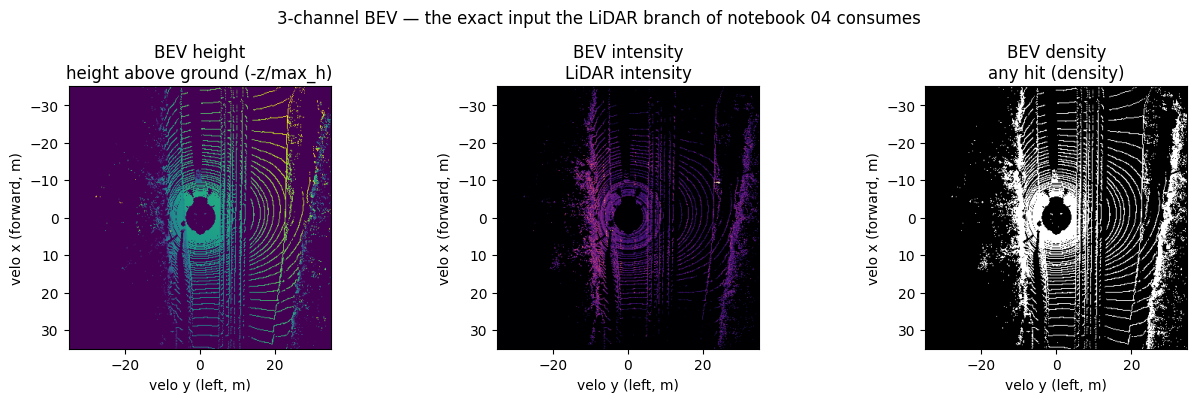

In [8]:
# ---- 3-channel BEV: mirrors common/geometry/bev.py:points_to_bev_image ----
def points_to_bev_image(points, range_m=RANGE, res=RES, max_h=MAXH):
    """(N,>=4) velo points -> (Hg, Wg, 3) BEV image [height, intensity, density]."""
    img = np.zeros((Hg, Wg, 3), np.float32)
    x, y, z = points[:, 0], points[:, 1], points[:, 2]
    inten = points[:, 3] if points.shape[1] >= 4 else np.zeros_like(x)
    r = ((x + range_m) / res).astype(int); c = ((y + range_m) / res).astype(int)
    m = (r >= 0) & (r < Hg) & (c >= 0) & (c < Wg)
    r, c, y_, z_, inten = r[m], c[m], y[m], z[m], inten[m]
    hgt = np.clip(-z_ / max(max_h, 1e-6), 0, 1)           # height above ground, normalized
    o = np.argsort(-hgt)                                    # tall points on top (last writer)
    r, c, hgt, inten = r[o], c[o], hgt[o], inten[o]
    img[r, c, 0] = hgt.astype(np.float32)
    img[r, c, 1] = inten.astype(np.float32)
    img[r, c, 2] = 1.0                                     # density
    return img

bev_img = points_to_bev_image(pts_in)
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for i, (n, cm, t) in enumerate(zip(["height", "intensity", "density"],
                                   ["viridis", "magma", "gray"],
                                   ["height above ground (-z/max_h)", "LiDAR intensity", "any hit (density)"])):
    ax[i].imshow(bev_img[..., i], cmap=cm, extent=[-RANGE, RANGE, RANGE, -RANGE])
    ax[i].set_title(f"BEV {n}\n{t}"); ax[i].set_xlabel("velo y (left, m)"); ax[i].set_ylabel("velo x (forward, m)")
plt.suptitle("3-channel BEV — the exact input the LiDAR branch of notebook 04 consumes")
plt.tight_layout(); plt.show()


## Bonus: project points to the camera image

The `.bin` is in the velo frame; the image is in pixels. The `calib/<id>.txt` file gives the
transform `velo -> cam -> image`. This is what `common/sensors/projection.py` does. We parse
the calib by hand (it's just `P2:` and `Tr_velo_to_cam:` lines of numbers) and project. If a
real image file is present we overlay on it; otherwise we scatter the `(u, v)` pixels alone.

In [9]:
# ---- parse calib + project points to pixels (mirrors common/sensors/projection.py) ----
def parse_calib(path):
    """Read a KITTI calib txt -> dict with P2 (3x4) and Tr_velo_to_cam (3x4)."""
    out = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            key, vals = line.split(":", 1)
            key = key.strip()
            if key in ("P2", "P3", "P0", "P1", "Tr_velo_to_cam", "Tr_imu_to_velo", "R0_rect"):
                out[key] = np.array([float(v) for v in vals.split()], np.float64)
    P2 = out["P2"].reshape(3, 4)
    Tr = out["Tr_velo_to_cam"].reshape(3, 4)
    R0 = np.eye(4); R0[:3, :3] = out.get("R0_rect", np.eye(9)).reshape(3, 3)
    return P2, Tr, R0

calib_path = os.path.join(SAMPLE_DIR, "calib", f"{FRAME_ID:06d}.txt")
if os.path.exists(calib_path):
    P2, Tr, R0 = parse_calib(calib_path)
    fx, fy, cx, cy = P2[0, 0], P2[1, 1], P2[0, 2], P2[1, 2]
    print(f"calib loaded from {calib_path}")
    print(f"  fx={fx:.1f} fy={fy:.1f} cx={cx:.1f} cy={cy:.1f}")
    print(f"  Tr_velo_to_cam (first row): {Tr[0].round(4).tolist()}")
    # velo -> cam (rect): R0 @ [Tr ; 0 1]
    n = len(pts_in)
    velo_h = np.hstack([pts_in[:, :3], np.ones((n, 1))])
    T = np.eye(4); T[:3, :] = Tr
    cam = (R0 @ T @ velo_h.T).T[:, :3]
    depth = cam[:, 2]
    u = (cam[:, 0] * fx) / np.where(depth == 0, 1e-9, depth) + cx
    v = (cam[:, 1] * fy) / np.where(depth == 0, 1e-9, depth) + cy
    m = depth > 0
    u, v, depth = u[m], v[m], depth[m]
    print(f"  projected {m.sum():,} points to image (depth in [{depth.min():.1f}, {depth.max():.1f}] m)")
else:
    print("no calib file -> skipping projection bonus cell")
    u = v = depth = None


calib loaded from data/kitti_sample\calib\000001.txt
  fx=721.5 fy=721.5 cx=609.6 cy=172.9
  Tr_velo_to_cam (first row): [0.0075, -1.0, -0.0006, -0.0041]
  projected 59,315 points to image (depth in [0.0, 34.7] m)


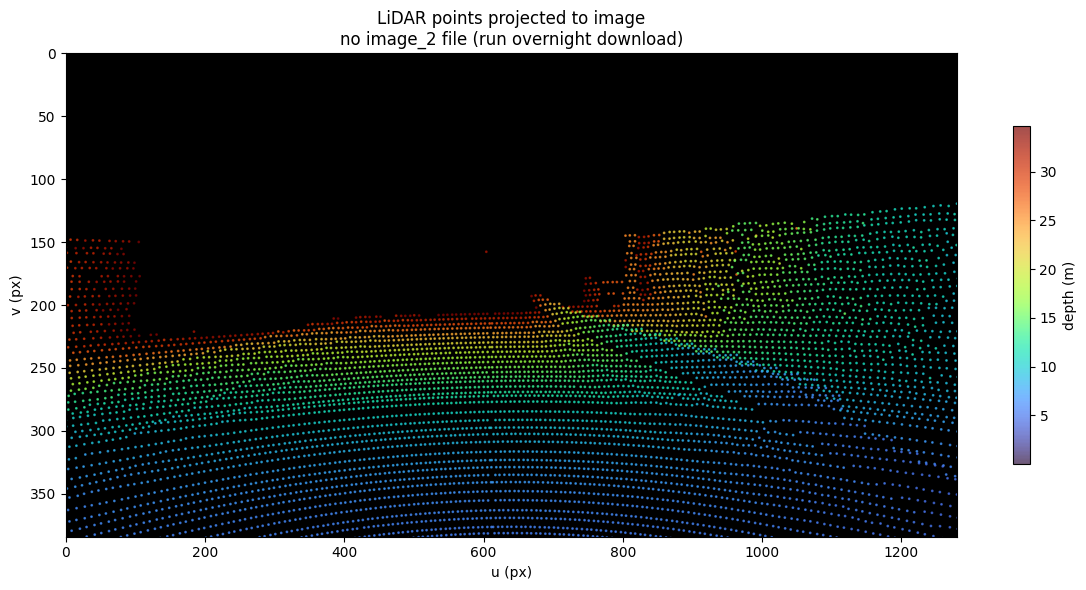

If you see the overlay: the colored dots are where each LiDAR point lands on the camera.
If no image: the full 12 GB image_2.zip is in the overnight download (data/kitti_download.sh).


In [10]:
# ---- plot the projection: overlay on image if available, else scatter (u, v) ----
img_path = os.path.join(SAMPLE_DIR, "image_2", f"{FRAME_ID:06d}.png")
has_image = os.path.exists(img_path)

fig, ax = plt.subplots(figsize=(12, 6))
if u is not None:
    if has_image:
        import matplotlib.image as mpimg
        img = mpimg.imread(img_path)
        ax.imshow(img, extent=[0, img.shape[1], img.shape[0], 0])
        ax.set_xlim(0, img.shape[1]); ax.set_ylim(img.shape[0], 0)
    else:
        ax.set_facecolor("black")
        ax.set_xlim(0, 1280); ax.set_ylim(384, 0)
    sc = ax.scatter(u[::3], v[::3], c=depth[::3], cmap="turbo", s=1.0, alpha=0.7)
    fig.colorbar(sc, ax=ax, shrink=0.7, label="depth (m)")
    ax.set_xlabel("u (px)"); ax.set_ylabel("v (px)")
    ax.set_title(f"LiDAR points projected to image\n{'overlay on ' + os.path.basename(img_path) if has_image else 'no image_2 file (run overnight download)'}")
else:
    ax.text(0.5, 0.5, "no calib -> projection skipped", ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()
plt.tight_layout(); plt.show()
print("If you see the overlay: the colored dots are where each LiDAR point lands on the camera.")
print("If no image: the full 12 GB image_2.zip is in the overnight download (data/kitti_download.sh).")


## Bonus: overlay 3D boxes on the BEV

The `label_2/<id>.txt` file lists the annotated objects: `type x1 y1 x2 y2 h w l x y z ry`.
The 3D fields `(x, y, z, w, h, l, ry)` are in the **cam frame** (x right, y down, z forward).
To draw them on the velo-frame BEV we just built, we project each box's center to the velo
frame and draw a rotated footprint. This connects to notebook 04's `_bev_polygon`.

labels loaded from data/kitti_sample\label_2\000001.txt: 3 annotated objects
  Truck: cam xyz=(0.5,1.5,69.4)  whl=(2.6,2.9,12.3)  ry=-1.56
  Car: cam xyz=(-16.5,2.4,58.5)  whl=(1.9,1.7,3.7)  ry=1.57
  Cyclist: cam xyz=(4.6,1.3,45.8)  whl=(0.6,1.9,2.0)  ry=-1.55


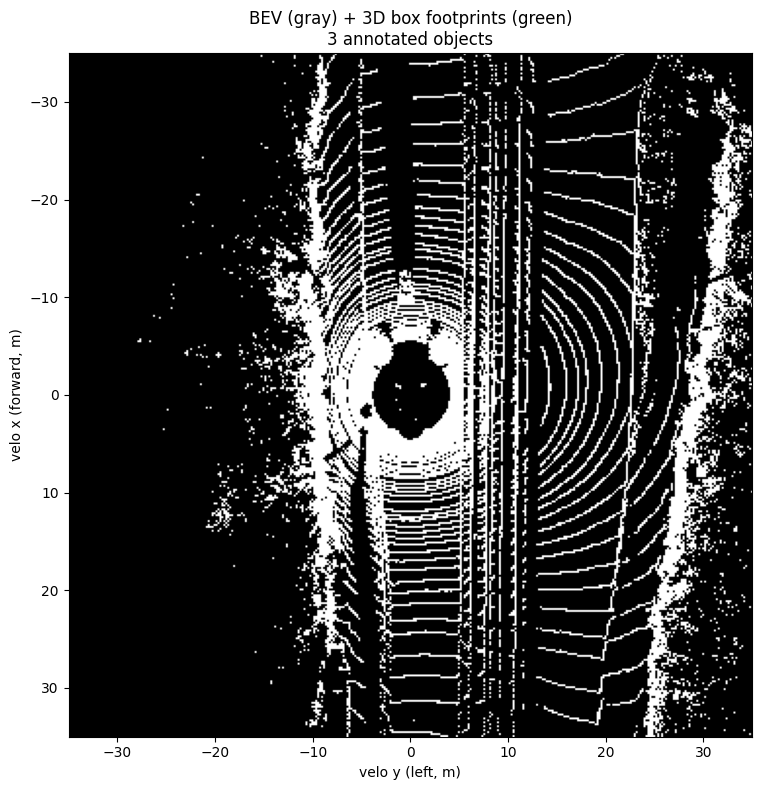

In [11]:
# ---- parse label_2 + overlay 3D box footprints on the BEV (velo frame) ----
def parse_labels(path, classes=("Car", "Truck", "Cyclist", "Pedestrian")):
    boxes = []
    if not os.path.exists(path): return boxes
    with open(path) as f:
        for line in f:
            p = line.strip().split()
            if not p or p[0] not in classes: continue
            h, w, l = float(p[8]), float(p[9]), float(p[10])
            x, y, z = float(p[11]), float(p[12]), float(p[13])
            ry = float(p[14])
            boxes.append(dict(cls=p[0], h=h, w=w, l=l, x=x, y=y, z=z, ry=ry))
    return boxes

def cam_box_to_velo_footprint(box, Tr, R0):
    """Box center (cam) -> velo (x, z=forward, y=left) footprint corners for BEV."""
    # cam center -> velo: invert R0 @ Tr
    T = np.eye(4); T[:3, :] = Tr
    M = np.eye(4); M[:3, :3] = R0[:3, :3]
    M_inv = np.linalg.inv(M @ T)
    cx, cy, cz = box["x"], box["y"] - box["h"]/2, box["z"]
    velo_c = (M_inv @ np.array([cx, cy, cz, 1.0]))[:3]
    # footprint in velo: length along velo x (forward), width along velo y (left)
    # ry is cam-frame yaw about y (down); to first order, footprint in velo (x, y)
    cos_r, sin_r = np.cos(box["ry"]), np.sin(box["ry"])
    dx = np.array([box["l"]/2, -box["l"]/2, -box["l"]/2, box["l"]/2])
    dy = np.array([box["w"]/2, box["w"]/2, -box["w"]/2, -box["w"]/2])
    rx = velo_c[0] + dx*cos_r - dy*sin_r   # forward
    ry_ = velo_c[1] + dx*sin_r + dy*cos_r  # left
    return list(zip(rx, ry_)), velo_c

label_path = os.path.join(SAMPLE_DIR, "label_2", f"{FRAME_ID:06d}.txt")
boxes = parse_labels(label_path)
print(f"labels loaded from {label_path}: {len(boxes)} annotated objects")
for b in boxes:
    print(f"  {b['cls']}: cam xyz=({b['x']:.1f},{b['y']:.1f},{b['z']:.1f})  whl=({b['w']:.1f},{b['h']:.1f},{b['l']:.1f})  ry={b['ry']:.2f}")

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(bev, cmap="gray", extent=[-RANGE, RANGE, RANGE, -RANGE])
if os.path.exists(calib_path):
    for b in boxes:
        corners, center = cam_box_to_velo_footprint(b, Tr, R0)
        poly = corners + [corners[0]]
        ax.plot([p[0] for p in poly], [p[1] for p in poly], "lime", lw=1.8)
        ax.plot(center[0], center[1], "g+", ms=10, mew=2)
ax.set_xlim(-RANGE, RANGE); ax.set_ylim(RANGE, -RANGE)
ax.set_xlabel("velo y (left, m)"); ax.set_ylabel("velo x (forward, m)")
ax.set_title(f"BEV (gray) + 3D box footprints (green)\n{len(boxes)} annotated objects")
plt.tight_layout(); plt.show()


## Recap

- **Load:** `np.fromfile(path, dtype=np.float32).reshape(-1, 4)` — a point cloud is just an
  unstructured `(N, 4)` array of `(x, y, z, intensity)` in the velo frame. No header, no grid.
  (`data/loaders/paired_loader.py`)
- **3D scatter:** matplotlib (or open3d) shows the cloud as a 3D scatter — the road is the flat
  band, cars are blobs that stick up.
- **Range filter:** keep `|x|, |y| <= range` — ~115k raw points become ~40k in the driving box.
- **Color by height:** `-z` (height above ground) makes the road blue and cars warm in one image.
- **Manual BEV:** bin `(x, y)` into a 2D grid with 3 lines of numpy — the 10-line exercise. This
  is the core of `common/geometry/bev.py`.
- **3-channel BEV:** `[height, intensity, density]` per cell — the exact input the LiDAR branch
  of notebook 04 consumes (`PillarBEVEncoder`).
- **Projection:** `calib` gives `velo -> cam -> image`; overlay LiDAR on the camera image.
  (`common/sensors/projection.py`)
- **3D boxes:** `label_2` gives cam-frame `(x,y,z,w,h,l,ry)`; project to velo and draw footprints
  on the BEV — the same `_bev_polygon` idea from notebook 04.

Every number above came from a **real KITTI `.bin`** (`data/kitti_sample/velodyne/000000.bin`).
The full dataset is `bash data/kitti_download.sh` (~27 GB velodyne + 12 GB images, run it
overnight); once `data/kitti/` exists, the repo's `KittiPairedDataset` picks it up automatically
and you can train the four fusion variants on real data.
